### # Step 1: Import dependencies

In [3]:
# Step 1: Import dependencies
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping

# Set base path
base_path = r"C:\Users\KIIT\Downloads\archive (2)\PlantVillage\PlantVillage"

# Check if path exists
if not os.path.exists(base_path):
    raise FileNotFoundError(f"Dataset path not found: {base_path}")
else:
    print("Dataset path verified.")

Dataset path verified.


### Step 2: Data loading and preprocessing

In [5]:
# Step 2: Data loading and preprocessing

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    base_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    subset='training',
    class_mode='categorical'
)

val_data = datagen.flow_from_directory(
    base_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    subset='validation',
    class_mode='categorical'
)

print(f"Total classes found: {len(train_data.class_indices)}")
print("Classes:", train_data.class_indices)


Found 16516 images belonging to 15 classes.
Found 4122 images belonging to 15 classes.
Total classes found: 15
Classes: {'Pepper__bell___Bacterial_spot': 0, 'Pepper__bell___healthy': 1, 'Potato___Early_blight': 2, 'Potato___Late_blight': 3, 'Potato___healthy': 4, 'Tomato_Bacterial_spot': 5, 'Tomato_Early_blight': 6, 'Tomato_Late_blight': 7, 'Tomato_Leaf_Mold': 8, 'Tomato_Septoria_leaf_spot': 9, 'Tomato_Spider_mites_Two_spotted_spider_mite': 10, 'Tomato__Target_Spot': 11, 'Tomato__Tomato_YellowLeaf__Curl_Virus': 12, 'Tomato__Tomato_mosaic_virus': 13, 'Tomato_healthy': 14}


### Step 3: Define CNN model function

In [7]:
# Step 3: Define CNN model function

def build_cnn_model(input_shape, filters1=32, filters2=64, dense_units=128, dropout_rate=0.5, lr=1e-3):
    model = models.Sequential([
        layers.Conv2D(filters1, (3,3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(filters2, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2)),

        layers.Flatten(),
        layers.Dense(dense_units, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(len(train_data.class_indices), activation='softmax')
    ])

    model.compile(optimizer=optimizers.Adam(learning_rate=lr),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model


### Step 4: Train baseline CNN

In [9]:
# Step 4: Train baseline CNN

EPOCHS_BASELINE = 12

model_baseline = build_cnn_model(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    filters1=32,
    filters2=64,
    dense_units=128,
    dropout_rate=0.5,
    lr=1e-3
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
]

history_baseline = model_baseline.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS_BASELINE,
    callbacks=callbacks
)


C:\Users\KIIT\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\KIIT\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/12
517/517 ━━━━━━━━━━━━━━━━━━━━ 529s 1s/step - accuracy: 0.3324 - loss: 2.1241 - val_accuracy: 0.6994 - val_loss: 0.9399
Epoch 2/12
517/517 ━━━━━━━━━━━━━━━━━━━━ 148s 286ms/step - accuracy: 0.6627 - loss: 1.0358 - val_accuracy: 0.7935 - val_loss: 0.6319
Epoch 3/12
517/517 ━━━━━━━━━━━━━━━━━━━━ 143s 276ms/step - accuracy: 0.7452 - loss: 0.7533 - val_accuracy: 0.8248 - val_loss: 0.5179
Epoch 4/12
517/517 ━━━━━━━━━━━━━━━━━━━━ 142s 274ms/step - accuracy: 0.7925 - loss: 0.6172 - val_accuracy: 0.8326 - val_loss: 0.5012
Epoch 5/12
517/517 ━━━━━━━━━━━━━━━━━━━━ 142s 276ms/step - accuracy: 0.8205 - loss: 0.5212 - val_accuracy: 0.8464 - val_loss: 0.4603
Epoch 6/12
517/517 ━━━━━━━━━━━━━━━━━━━━ 142s 275ms/step - accuracy: 0.8483 - loss: 0.4462 - val_accuracy: 0.8588 - val_loss: 0.4328
Epoch 7/12
517/517 ━━━━━━━━━━━━━━━━━━━━ 146s 281ms/step - accuracy: 0.8592 - loss: 0.3957 - val_accuracy: 0.8559 - val_loss: 0.4254
Epoch 8/12
517/517 ━━━━━━━━━━━━━━━━━━━━ 142s 274ms/step - accuracy: 0.8776 - lo

### Step 5: Plot accuracy and loss

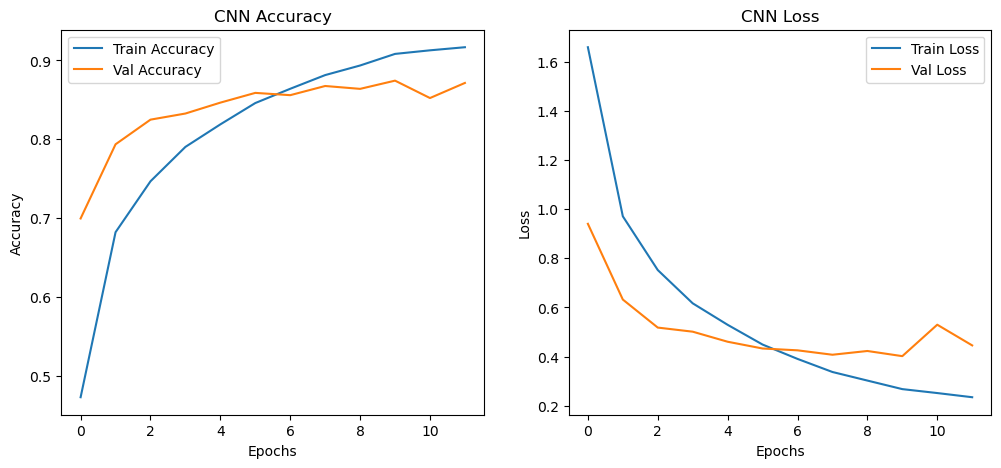

In [11]:
# Step 5: Plot accuracy and loss

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_baseline.history['accuracy'], label='Train Accuracy')
plt.plot(history_baseline.history['val_accuracy'], label='Val Accuracy')
plt.title('CNN Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_baseline.history['loss'], label='Train Loss')
plt.plot(history_baseline.history['val_loss'], label='Val Loss')
plt.title('CNN Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


In [15]:
pip install pyswarms

  Using cached pyswarms-1.3.0-py2.py3-none-any.whl.metadata (33 kB)
  Using cached future-1.0.0-py3-none-any.whl.metadata (4.0 kB)
Using cached pyswarms-1.3.0-py2.py3-none-any.whl (104 kB)
Using cached future-1.0.0-py3-none-any.whl (491 kB)
Note: you may need to restart the kernel to use updated packages.


### Step 6  CNN + PSO

In [18]:
# Step 6  Fast CNN + PSO
import numpy as np
import pyswarms as ps
from tensorflow.keras import backend as K
import time

# Search space: [log10_lr, dropout]
bounds_lower = [np.log10(1e-5), 0.1]
bounds_upper = [np.log10(1e-2), 0.6]
bounds = (np.array(bounds_lower), np.array(bounds_upper))

def particle_to_params_light(x):
    lr = 10 ** float(x[0])
    dropout = float(np.clip(x[1], 0.05, 0.7))
    return {'lr': lr, 'dropout': dropout}

EPOCHS_PSO = 1  # keep 1 for speed

def fitness_function_light(X):
    """Simplified fitness — tune lr + dropout only."""
    n_particles = X.shape[0]
    fitness = np.zeros(n_particles)
    for i in range(n_particles):
        params = particle_to_params_light(X[i])
        print(f"[Particle {i}] params:", params)
        
        model = build_cnn_model(
            input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
            filters1=32,
            filters2=64,
            dense_units=128,
            dropout_rate=params['dropout'],
            lr=params['lr']
        )
        try:
            h = model.fit(
                train_data,
                validation_data=val_data,
                epochs=EPOCHS_PSO,
                verbose=0
            )
            val_acc = h.history['val_accuracy'][-1]
            fitness[i] = 1.0 - float(val_acc)
            print(f"  -> val_acc: {val_acc:.4f}")
        except Exception as e:
            print("Error:", e)
            fitness[i] = 1.0
        finally:
            K.clear_session()
            del model
            time.sleep(0.3)
    return fitness

# PSO setup
options = {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
n_particles = 3
iters = 3

optimizer = ps.single.GlobalBestPSO(n_particles=n_particles, dimensions=2, options=options, bounds=bounds)
print("Starting light PSO...")
t0 = time.time()
best_cost, best_pos = optimizer.optimize(fitness_function_light, iters=iters, verbose=True)
print(f"Light PSO done in {(time.time()-t0):.1f}s")

best_params = particle_to_params_light(best_pos)
print("Best PSO params:", best_params)


2025-11-02 18:06:54,140 - pyswarms.single.global_best - INFO - Optimize for 3 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}


Starting light PSO...


pyswarms.single.global_best:   0%|                                                                                 |0/3

[Particle 0] params: {'lr': 9.577260423855733e-05, 'dropout': 0.5549321236271784}
  -> val_acc: 0.5378
[Particle 1] params: {'lr': 0.006018090798957328, 'dropout': 0.2794281008379633}
  -> val_acc: 0.5308
[Particle 2] params: {'lr': 0.002395887785362229, 'dropout': 0.5110047439741409}
  -> val_acc: 0.6730


pyswarms.single.global_best:  33%|█████████████████████▎                                          |1/3, best_cost=0.327

[Particle 0] params: {'lr': 0.0004462725093356233, 'dropout': 0.39543950287278595}
  -> val_acc: 0.7089
[Particle 1] params: {'lr': 3.665686235194763e-05, 'dropout': 0.3716566206423027}
  -> val_acc: 0.5306
[Particle 2] params: {'lr': 0.008593203989713324, 'dropout': 0.2816737437849546}
  -> val_acc: 0.5374


pyswarms.single.global_best:  67%|██████████████████████████████████████████▋                     |2/3, best_cost=0.291

[Particle 0] params: {'lr': 0.0017828840061575697, 'dropout': 0.1518961441938327}
  -> val_acc: 0.6892
[Particle 1] params: {'lr': 0.0004186847068514104, 'dropout': 0.42232762230191084}
  -> val_acc: 0.6577
[Particle 2] params: {'lr': 1.1621617080285937e-05, 'dropout': 0.5917766757722072}
  -> val_acc: 0.3816


pyswarms.single.global_best: 100%|████████████████████████████████████████████████████████████████|3/3, best_cost=0.291
2025-11-02 18:37:49,073 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.29112082719802856, best pos: [-3.35039987  0.3954395 ]


Light PSO done in 1854.9s
Best PSO params: {'lr': 0.0004462725093356233, 'dropout': 0.39543950287278595}


### Retrain final CNN with tuned learning rate and dropout

In [20]:
# Retrain final CNN with tuned learning rate and dropout
final_lr = best_params['lr']
final_dropout = best_params['dropout']

model_pso = build_cnn_model(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    filters1=32,
    filters2=64,
    dense_units=128,
    dropout_rate=final_dropout,
    lr=final_lr
)

EPOCHS_FINAL = 10  # can increase for final evaluation
history_pso = model_pso.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS_FINAL,
    verbose=1
)

# Compare results
baseline_best = max(history_baseline.history['val_accuracy'])
pso_best = max(history_pso.history['val_accuracy'])
print(f"Baseline Val Acc: {baseline_best:.4f}")
print(f"PSO-Tuned Val Acc: {pso_best:.4f}")

Epoch 1/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 210s 397ms/step - accuracy: 0.3738 - loss: 1.9732 - val_accuracy: 0.7239 - val_loss: 0.9366
Epoch 2/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 195s 377ms/step - accuracy: 0.6513 - loss: 1.0628 - val_accuracy: 0.7797 - val_loss: 0.7207
Epoch 3/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 214s 414ms/step - accuracy: 0.7173 - loss: 0.8476 - val_accuracy: 0.8147 - val_loss: 0.5589
Epoch 4/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 205s 397ms/step - accuracy: 0.7610 - loss: 0.7024 - val_accuracy: 0.8467 - val_loss: 0.4888
Epoch 5/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 205s 397ms/step - accuracy: 0.7904 - loss: 0.6087 - val_accuracy: 0.8552 - val_loss: 0.4300
Epoch 6/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 216s 417ms/step - accuracy: 0.8187 - loss: 0.5197 - val_accuracy: 0.8627 - val_loss: 0.4258
Epoch 7/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 210s 405ms/step - accuracy: 0.8350 - loss: 0.4796 - val_accuracy: 0.8678 - val_loss: 0.3905
Epoch 8/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 200s 386ms/step - accuracy: 0.8525 -

### Step 7: Compare baseline CNN vs CNN+PSO

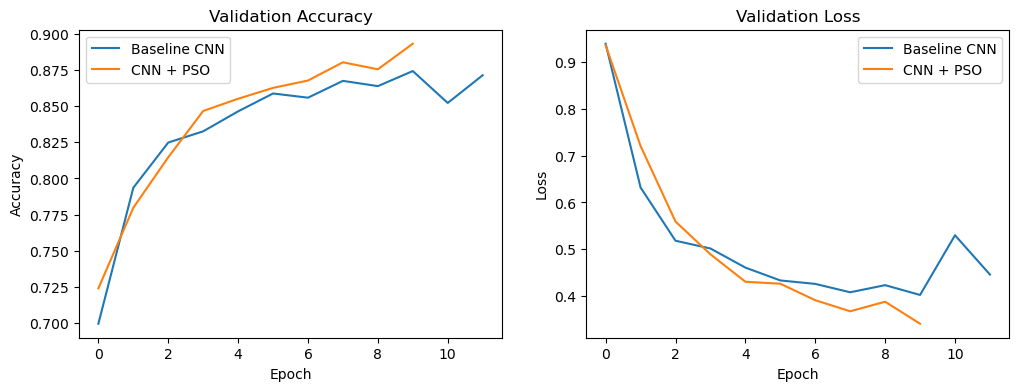

Baseline CNN best val acc: 87.43%
CNN + PSO best val acc: 89.33%


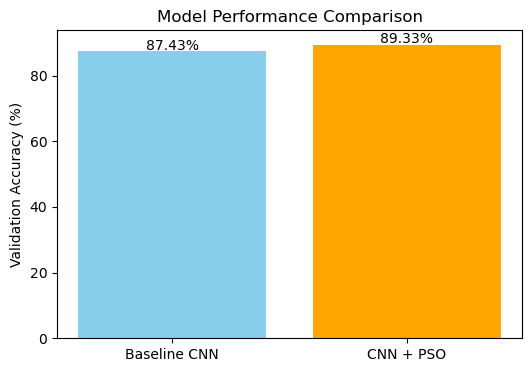

In [56]:
# Step 7: Compare baseline CNN vs CNN+PSO
import matplotlib.pyplot as plt

# 1️⃣ Plot accuracy curves
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history_baseline.history['val_accuracy'], label='Baseline CNN')
plt.plot(history_pso.history['val_accuracy'], label='CNN + PSO')
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# 2️⃣ Plot loss curves
plt.subplot(1,2,2)
plt.plot(history_baseline.history['val_loss'], label='Baseline CNN')
plt.plot(history_pso.history['val_loss'], label='CNN + PSO')
plt.title('Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# 3️⃣ Print best accuracies
baseline_best = max(history_baseline.history['val_accuracy'])
pso_best = max(history_pso.history['val_accuracy'])
print(f"Baseline CNN best val acc: {baseline_best*100:.2f}%")
print(f"CNN + PSO best val acc: {pso_best*100:.2f}%")

# 4️⃣ Bar chart comparison
labels = ['Baseline CNN', 'CNN + PSO']
vals = [baseline_best*100, pso_best*100]
plt.figure(figsize=(6,4))
plt.bar(labels, vals, color=['skyblue', 'orange'])
for i, v in enumerate(vals):
    plt.text(i, v + 0.5, f"{v:.2f}%", ha='center')
plt.ylabel("Validation Accuracy (%)")
plt.title("Model Performance Comparison")
plt.show()

In [26]:
model_baseline.save("cnn_baseline.h5")
model_pso.save("cnn_pso_tuned.h5")
print("Models saved successfully.")


2025-11-02 19:43:45,402 - absl - WARNING - You are saving your model as an HDF5 file via `model.save()` or `keras.saving.save_model(model)`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')` or `keras.saving.save_model(model, 'my_model.keras')`. 
2025-11-02 19:43:45,620 - absl - WARNING - You are saving your model as an HDF5 file via `model.save()` or `keras.saving.save_model(model)`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')` or `keras.saving.save_model(model, 'my_model.keras')`. 


Models saved successfully.


In [42]:
from tensorflow.keras.models import load_model

# Load both trained models
cnn_model = load_model("cnn_baseline.h5")
cnn_pso_model = load_model("cnn_pso_tuned.h5")

2025-11-02 21:25:28,283 - absl - WARNING - Compiled the loaded model, but the compiled metrics have yet to be built. `model.compile_metrics` will be empty until you train or evaluate the model.
2025-11-02 21:25:28,404 - absl - WARNING - Compiled the loaded model, but the compiled metrics have yet to be built. `model.compile_metrics` will be empty until you train or evaluate the model.


In [52]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

base_path = r"C:\Users\KIIT\Downloads\archive (2)\PlantVillage\PlantVillage"
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
train_data = datagen.flow_from_directory(
    base_path,
    target_size=(128,128),
    batch_size=32,
    subset='training',
    class_mode='categorical'
)
print(train_data.class_indices)

Found 16516 images belonging to 15 classes.
{'Pepper__bell___Bacterial_spot': 0, 'Pepper__bell___healthy': 1, 'Potato___Early_blight': 2, 'Potato___Late_blight': 3, 'Potato___healthy': 4, 'Tomato_Bacterial_spot': 5, 'Tomato_Early_blight': 6, 'Tomato_Late_blight': 7, 'Tomato_Leaf_Mold': 8, 'Tomato_Septoria_leaf_spot': 9, 'Tomato_Spider_mites_Two_spotted_spider_mite': 10, 'Tomato__Target_Spot': 11, 'Tomato__Tomato_YellowLeaf__Curl_Virus': 12, 'Tomato__Tomato_mosaic_virus': 13, 'Tomato_healthy': 14}


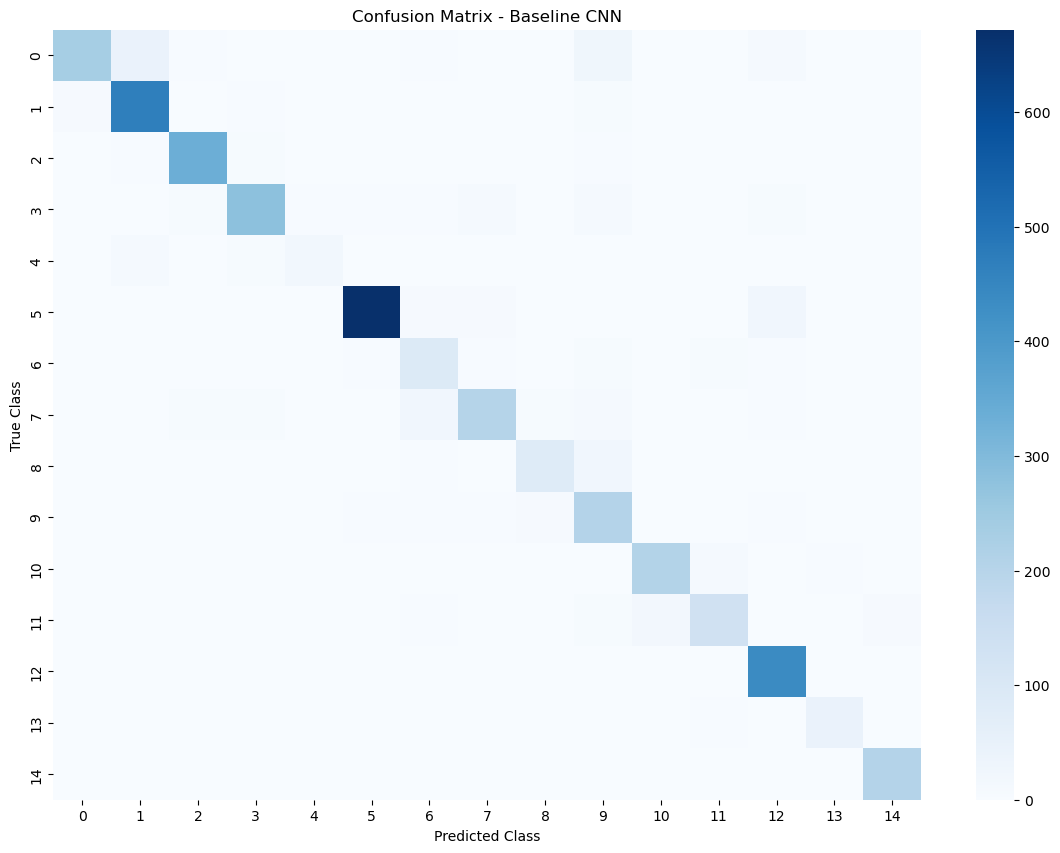

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.95      0.71      0.81       331
                     Pepper__bell___healthy       0.88      0.96      0.92       491
                      Potato___Early_blight       0.93      0.96      0.95       347
                       Potato___Late_blight       0.91      0.84      0.87       332
                           Potato___healthy       0.88      0.47      0.61        49
                      Tomato_Bacterial_spot       0.97      0.94      0.96       717
                        Tomato_Early_blight       0.62      0.73      0.67       125
                         Tomato_Late_blight       0.86      0.77      0.81       265
                           Tomato_Leaf_Mold       0.83      0.71      0.77       119
                  Tomato_Septoria_leaf_spot       0.66      0.84      0.74       246
Tomato_Spider_mites_Two_spotted_spider_mite       0.89      0.91

In [60]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Make sure generator does not shuffle — for correct label ordering
val_data.shuffle = False

# Number of samples
num_samples = val_data.samples

y_true = []
y_pred = []

# Loop through validation generator
for i in range(len(val_data)):
    images, labels = next(val_data)
    
    preds = model_baseline.predict(images, verbose=0)
    
    y_true.extend(np.argmax(labels, axis=1))
    y_pred.extend(np.argmax(preds, axis=1))
    
    # Stop when we've collected all validation samples
    if len(y_true) >= num_samples:
        break

y_true = np.array(y_true[:num_samples])
y_pred = np.array(y_pred[:num_samples])

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(14, 10))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.title("Confusion Matrix - Baseline CNN")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()

# Classification Report
print(classification_report(y_true, y_pred, target_names=list(val_data.class_indices.keys())))
